# 03 - Linearna regresija i regresija sa težinama

U ovoj svesci učimo prve modele nad podacima pripremljenim u svesci 02:

1. obična linearna regresija
2. linearna regresija sa težinama

Drugi model uvodimo zato što ćemo na grafiku reziduala prvog modela videti da rasipanje
greške nije jednako za sve vrednosti ciljne promenljive. To smo naslutili još u svesci 01,
gde je korelacija između proseka i standardne devijacije po satima bila 0.97.

Oba modela poredimo sa trivijalnom osnovom iz sveske 02.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn import linear_model
from sklearn import preprocessing
from sklearn import metrics

np.random.seed(7)

# Učitavanje pripremljenih podataka

In [2]:
paket = joblib.load('../data/pripremljeno.joblib')

X = paket['X']
y = paket['y']
kolone = paket['kolone']

h_trening = paket['h_trening']
h_validacija = paket['h_validacija']
h_test = paket['h_test']

n_trening = paket['n_trening']
n_validacija = paket['n_validacija']
n_test = paket['n_test']

Linearna regresija nema metaparametre koje bi trebalo podešavati, pa skup za validaciju u ovoj svesci nema šta da bira. Zato, po pravilu iz sveske 02, model obučavamo odmah na uniji skupova za treniranje i validaciju. Tako svi modeli u projektu uče iz iste količine podataka, cele 2011. godine.

In [3]:
h_trening_validacija = h_trening | h_validacija

x_train = X[h_trening_validacija]
y_train = y[h_trening_validacija]

x_test = X[h_test]
y_test = y[h_test]

print('trening+validacija:', x_train.shape)
print('test:              ', x_test.shape)

trening+validacija: (8645, 52)
test:               (8734, 52)


# Standardizacija podataka

Statistike računamo samo na podacima za obučavanje, a zatim njima transformišemo i skup
za testiranje.

In [4]:
scaler = preprocessing.StandardScaler()
scaler.fit(x_train)

x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

# Funkcija za evaluaciju

Sve modele u projektu ocenjujemo istom funkcijom: srednja apsolutna greška, koren srednje
kvadratne greške, koeficijent determinacije i prosečna razlika predviđene i stvarne
vrednosti.

In [5]:
def oceni(y_stvarno, y_predvidjeno, naziv):
    mae = metrics.mean_absolute_error(y_stvarno, y_predvidjeno)
    rmse = np.sqrt(metrics.mean_squared_error(y_stvarno, y_predvidjeno))
    r2 = metrics.r2_score(y_stvarno, y_predvidjeno)
    odstupanje = np.mean(y_predvidjeno - y_stvarno)
    print('%-38s MAE %6.1f  RMSE %6.1f  R2 %6.3f  odstupanje %+7.1f'
          % (naziv, mae, rmse, r2, odstupanje))
    return {'model': naziv, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'odstupanje': odstupanje}

# Trivijalna osnova

Ponavljamo trivijalnu osnovu iz sveske 02, prosek po satu i tipu dana sa unije
skupova za treniranje i validaciju, da bismo je imali u istoj tabeli sa modelima.

In [6]:
sat = pd.read_csv('../data/hour.csv')

prosek_po_satu = sat[h_trening_validacija].groupby(['hr', 'workingday'])['cnt'].mean()
kljucevi = sat[h_test].set_index(['hr', 'workingday']).index
y_test_predicted_osnova = kljucevi.map(prosek_po_satu).to_numpy(dtype=float)

In [7]:
rezultati = []
rezultati.append(oceni(y_test, y_test_predicted_osnova, 'trivijalna osnova'))

trivijalna osnova                      MAE  108.5  RMSE  157.1  R2  0.435  odstupanje   -91.9


# Linearna regresija

Konstruišemo model i obučavamo ga na uniji skupova za treniranje i validaciju.

In [8]:
model = linear_model.LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

Pošto su atributi standardizovani, koeficijenti se mogu porediti međusobno.

In [9]:
print('slobodan član:', round(model.intercept_, 2))

slobodan član: 143.79


In [10]:
koeficijenti = pd.Series(model.coef_, index=kolone)

print('najveći pozitivni koeficijenti:')
print(koeficijenti.sort_values(ascending=False).head().round(2))

najveći pozitivni koeficijenti:
hr_17    57.27
hr_18    52.07
hr_8     44.76
hr_19    35.91
hr_16    33.31
dtype: float64


In [11]:
print('najveći negativni koeficijenti:')
print(koeficijenti.sort_values().head().round(2))

najveći negativni koeficijenti:
hum            -14.49
weathersit_3   -13.65
hr_4            -6.57
hr_3            -5.76
hr_5            -4.21
dtype: float64


Najveći pozitivan uticaj imaju sati 17, 18 i 8, dakle odlazak sa posla i dolazak na posao.
Najveći negativan uticaj imaju vlažnost, loše vreme i noćni sati. Model je naučio ono
što smo videli u analizi.

# Evaluacija modela

In [12]:
y_test_predicted = model.predict(x_test)

rezultati.append(oceni(y_test, y_test_predicted, 'linearna regresija'))

linearna regresija                     MAE  110.2  RMSE  158.0  R2  0.428  odstupanje   -86.7


Linearna regresija je, iako uči iz 52 atributa, ipak nešto lošija od trivijalne osnove.

Osnova predviđa prosek za par sata i tipa dana, pa koristi njihovu interakciju: sat 8 radnim danom je nešto sasvim drugo nego sat 8 vikendom. Linearna regresija ima i atribut za sat i atribut za tip dana, ali njihove uticaje sabira nezavisno i ne može da izrazi da se uticaj sata menja sa tipom dana.


# Grafik reziduala

Grafik reziduala prikazuje razliku stvarne i predviđene vrednosti u zavisnosti od stvarne
vrednosti. Ako pretpostavke linearne regresije važe, tačke su ravnomerno raspoređene oko
nule, sa istim rasipanjem duž cele x-ose.

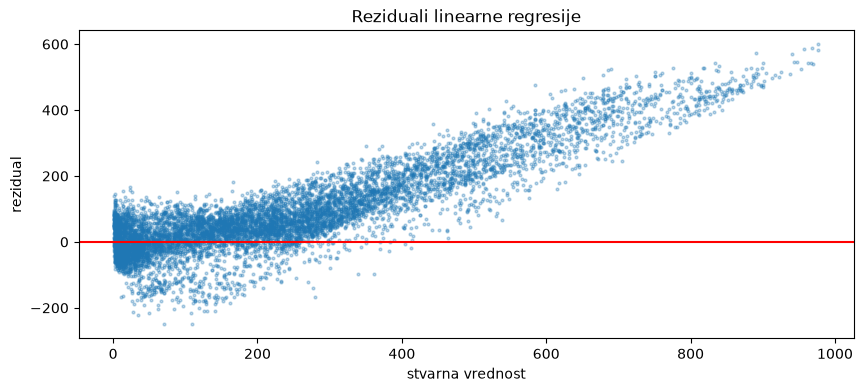

In [13]:
reziduali = y_test - y_test_predicted

plt.figure(figsize=(10, 4))
plt.scatter(y_test, reziduali, s=4, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel('stvarna vrednost')
plt.ylabel('rezidual')
plt.title('Reziduali linearne regresije')
plt.show()

Rasipanje reziduala raste sa stvarnom vrednošću. Za male vrednosti tačke su skupljene oko nule, a za velike se šire. Skup dakle nije homoskedastičan.

Proveravamo i brojčano, tako što skup za testiranje delimo na pet grupa po stvarnoj vrednosti i u svakoj računamo standardnu devijaciju reziduala.

In [14]:
grupe = pd.qcut(y_test, 5)
tabela = pd.DataFrame({'stvarno': y_test, 'rezidual': reziduali})

tabela.groupby(grupe, observed=True)['rezidual'].agg(['count', 'mean', 'std']).round(1)

,count,mean,std
"(0.999, 35.0]",1771,-4.6,51.0
"(35.0, 135.0]",1731,0.1,65.1
"(135.0, 245.0]",1744,38.8,57.7
"(245.0, 400.4]",1741,105.6,62.0
"(400.4, 977.0]",1747,294.2,108.1


Standardna devijacija reziduala je 51 u petini sa najmanjim vrednostima i 108 u petini sa najvećim, dakle oko dva puta veća. Pretpostavka o jednakoj varijansi ne važi.

U istoj tabeli se vidi i nešto drugo. Prosek reziduala raste od oko nule u dve najniže petine do 294 u najvišoj. Model dakle ne samo da više greši na velikim vrednostima, nego ih i sistematski potcenjuje.

# Linearna regresija sa težinama

Kod regresije sa težinama se umesto zbira kvadrata reziduala minimizuje njihov težinski zbir. Instance sa malom varijansom dobijaju veću težinu, a instance sa velikom varijansom manju, po formuli $w_i = 1 / \sigma_i^2$.

Pri tome je $\sigma_i^2$ varijansa šuma, dakle onoga što model ne može da objasni. U vežbi je ona bila poznata, jer je skup bio sintetički. Ovde je ne znamo, pa je ocenjujemo iz reziduala obične linearne regresije na podacima za obučavanje. Ne uzimamo rasipanje same ciljne promenljive, jer je u njemu i sve ono što model već objašnjava satom, tipom dana i vremenom.

Iz sveske 01 znamo da rasipanje najviše zavisi od sata u danu, pa varijansu reziduala računamo po satima.

In [15]:
reziduali_trening = y_train - model.predict(x_train)

varijansa_po_satu = pd.Series(reziduali_trening ** 2,
                              index=sat[h_trening_validacija]['hr'].values).groupby(level=0).mean()
varijansa_po_satu.round(0)

0      1916.0
1      2279.0
2      2354.0
3      2133.0
4      2120.0
5      1979.0
6      1960.0
7      9842.0
8     20309.0
9      2160.0
10     3651.0
11     5518.0
12     6882.0
13     7500.0
14     8279.0
15     7773.0
16     4998.0
17    15959.0
18    14686.0
19     5714.0
20     2766.0
21     1596.0
22     1039.0
23     1243.0
dtype: float64

In [16]:
weights = 1 / varijansa_po_satu[sat[h_trening_validacija]['hr']].to_numpy()

print('najveća težina: ', weights.max())
print('najmanja težina:', weights.min())
print('odnos:          ', round(weights.max() / weights.min(), 1))

najveća težina:  0.0009623348555287308
najmanja težina: 4.9238906079168304e-05
odnos:           19.5


Odnos najveće i najmanje težine je oko dvadeset. Noćni sati, u kojima model malo greši,
dobijaju veću težinu, a sati špica, u kojima su reziduali najveći, manju.

Težine zadajemo parametrom sample_weight metoda fit.

In [17]:
improved_model = linear_model.LinearRegression()
improved_model.fit(x_train, y_train, sample_weight=weights)

LinearRegression()

In [18]:
y_test_predicted_improved = improved_model.predict(x_test)

rezultati.append(oceni(y_test, y_test_predicted_improved, 'linearna regresija sa težinama'))

linearna regresija sa težinama         MAE  110.3  RMSE  161.0  R2  0.406  odstupanje   -88.1


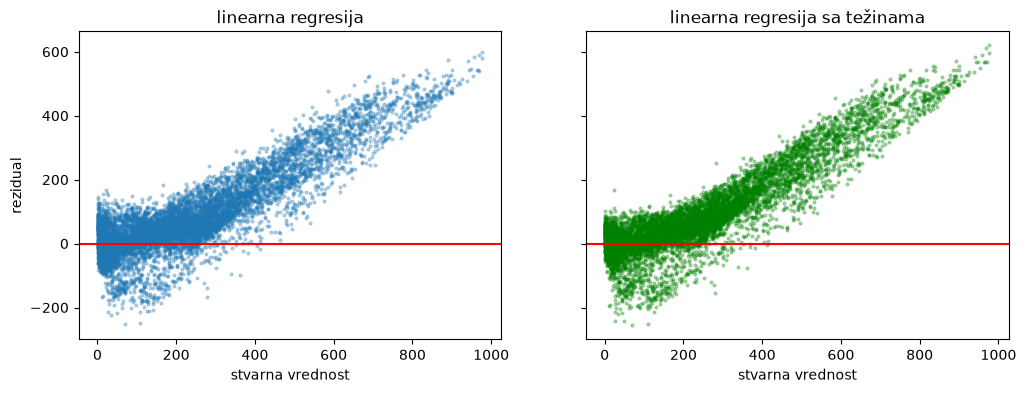

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

ax[0].scatter(y_test, reziduali, s=4, alpha=0.3)
ax[0].axhline(0, color='red')
ax[0].set_title('linearna regresija')
ax[0].set_xlabel('stvarna vrednost')
ax[0].set_ylabel('rezidual')

ax[1].scatter(y_test, y_test - y_test_predicted_improved, s=4, alpha=0.3, color='green')
ax[1].axhline(0, color='red')
ax[1].set_title('linearna regresija sa težinama')
ax[1].set_xlabel('stvarna vrednost')

plt.show()

Težine nisu popravile rezultat. Srednja apsolutna greška je praktično ista, a koren srednje kvadratne greške i koeficijent determinacije su nešto lošiji, jer model sada nešto više greši baš na velikim vrednostima.

Razlog je što rasipanje ovde ne dolazi od šuma u merenju, nego od stvarne pojave. U satima špica potražnja zaista jače varira, jer tada vreme i dan u nedelji najviše utiču. Smanjujući težinu tih instanci, model je smanjio pažnju na sate u kojima je najviše
informacije.


# Poređenje sa nasumičnom podelom

Isti model učimo na nasumičnoj podeli iz sveske 02, da bismo izmerili koliko ona
precenjuje rezultat.

In [20]:
n_trening_validacija = n_trening | n_validacija

scaler_n = preprocessing.StandardScaler()
scaler_n.fit(X[n_trening_validacija])

model_n = linear_model.LinearRegression()
model_n.fit(scaler_n.transform(X[n_trening_validacija]), y[n_trening_validacija])

LinearRegression()

In [21]:
oceni(y[n_test], model_n.predict(scaler_n.transform(X[n_test])), 'linearna regresija, nasumična')
oceni(y_test, y_test_predicted, 'linearna regresija, hronološka')
print()

linearna regresija, nasumična          MAE   75.3  RMSE  101.5  R2  0.687  odstupanje    +0.4
linearna regresija, hronološka         MAE  110.2  RMSE  158.0  R2  0.428  odstupanje   -86.7



Isti model, skupovi iste veličine, a greška na nasumičnoj podeli je za trećinu manja. Nasumična podela stavlja susedne sate i u trening i u test, pa model interpolira između gotovo istih vrednosti.

Razlika je i u odstupanju. Na hronološkoj podeli model potcenjuje potražnju za oko devedeset bicikala po satu, jer je naučen na 2011. a testiran na 2012. Na nasumičnoj podeli odstupanje je blizu nule, jer su obe godine u oba skupa.

# Zbirni prikaz

In [22]:
tabela_rezultata = pd.DataFrame(rezultati).set_index('model')
tabela_rezultata.round(3)

,MAE,RMSE,R2,odstupanje
model,,,,
trivijalna osnova,108.516,157.051,0.435,-91.874
linearna regresija,110.178,158.026,0.428,-86.715
linearna regresija sa težinama,110.297,161.012,0.406,-88.132


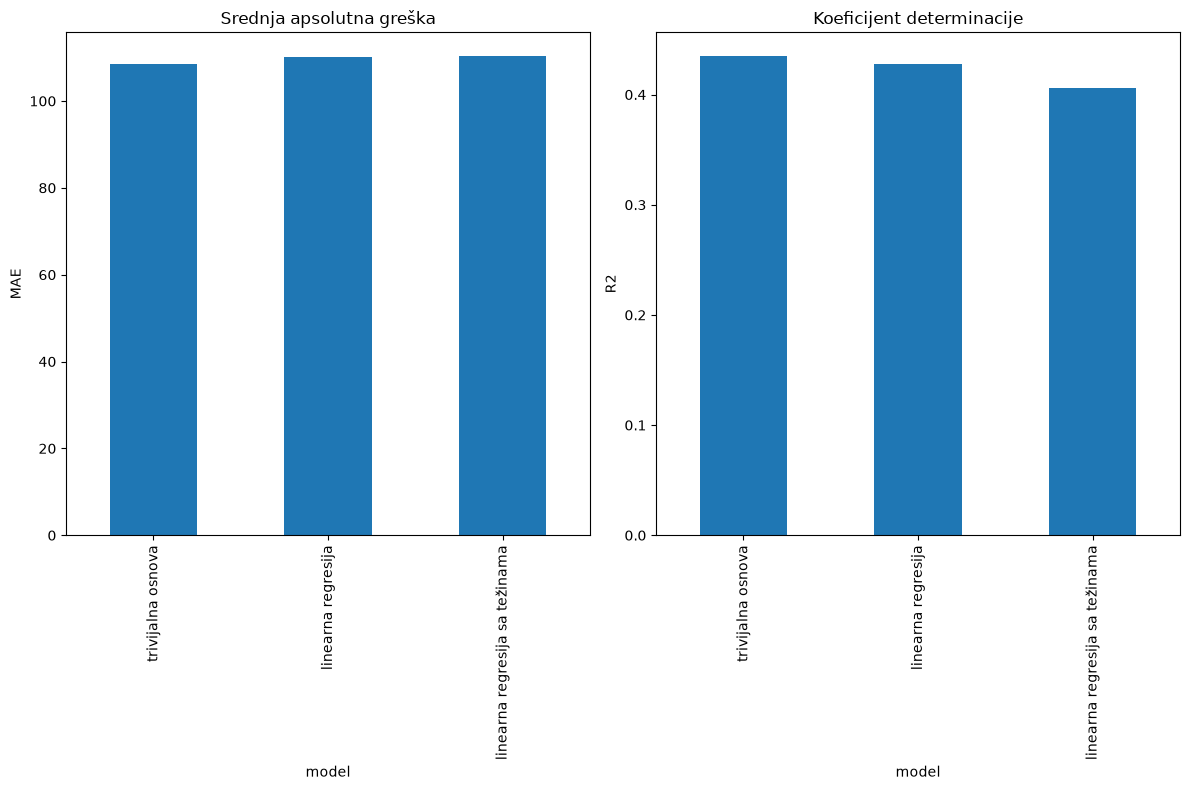

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 8))

tabela_rezultata['MAE'].plot(kind='bar', ax=ax[0])
ax[0].set_title('Srednja apsolutna greška')
ax[0].set_ylabel('MAE')

tabela_rezultata['R2'].plot(kind='bar', ax=ax[1])
ax[1].set_title('Koeficijent determinacije')
ax[1].set_ylabel('R2')

plt.tight_layout()
plt.show()

# Čuvanje modela

In [24]:
joblib.dump(model, '../models/03_linearna_regresija.joblib')
joblib.dump(improved_model, '../models/03_linearna_regresija_tezine.joblib')
joblib.dump(scaler, '../models/03_scaler.joblib')

tabela_rezultata.to_csv('../models/03_rezultati.csv')

print('sačuvano')

sačuvano


# Zaključci

1. Linearna regresija je lošija od trivijalne osnove, jer ne može da izrazi interakciju
   sata i tipa dana, a osnova je koristi.

2. Grafik reziduala pokazuje da rasipanje greške raste sa vrednošću ciljne promenljive.
   Standardna devijacija u grupi sa najvećim vrednostima je oko dva puta veća nego
   u grupi sa najmanjim.

3. Regresija sa težinama nije popravila rezultat, jer rasipanje ne potiče od šuma nego
   od stvarne promenljivosti u satima špica, pa smanjivanje težine tih instanci
   uklanja informaciju.

4. Nasumična podela daje osetno bolje brojeve od hronološke za isti model, što
   potvrđuje da za ovaj skup nasumična podela nije poštena procena.

